# Tópicos em Otimização Irrestrita

### Pacotes importados

In [91]:
using Plots

### Machine epsilon

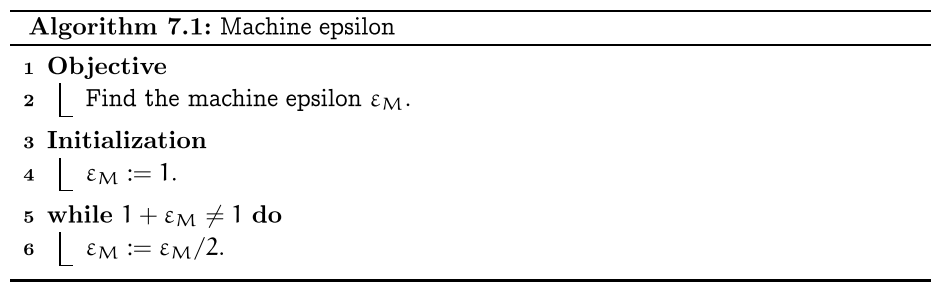

In [92]:
ε_M = 1.0

while 1.0 + ε_M != 1.0
    ε_M = ε_M / 2.0
end

ε_M = ε_M * 2.0  # Recupera o último valor que ainda satisfazia a condição

println("Machine epsilon: ε_M = ", ε_M)
println("eps() do Julia:  ", eps(Float64))

Machine epsilon: ε_M = 2.220446049250313e-16
eps() do Julia:  2.220446049250313e-16


### Newton's method: one variable

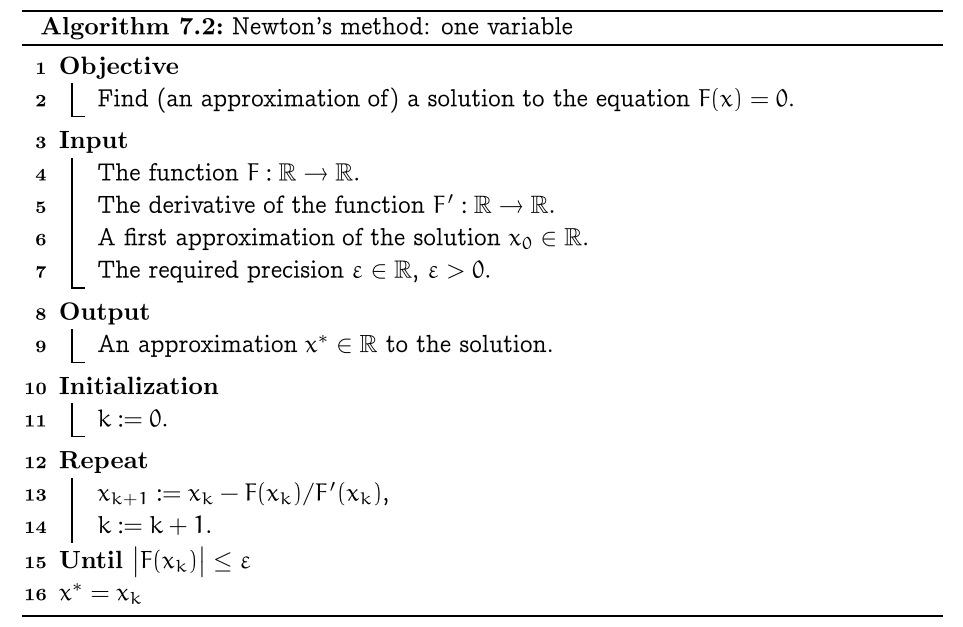

Take the equation: $F(x) = x^2 - 2 = 0$. Apply the Newton's method with $x_0 = 2, \epsilon = 10^{-15}$. Present the results such as the following:

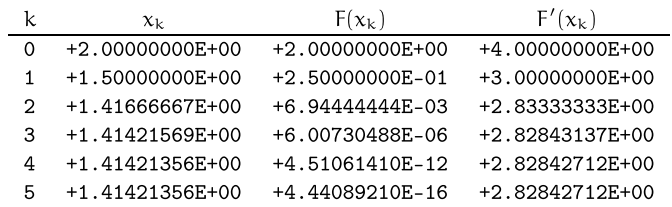

Also plot the graph with the iterations $\times$ the value of F(x).

k 	 xk 			 F(xk) 			 F'(xk)
0 	 +2.00000000E+00 	 +2.00000000E+00 	 +4.00000000E+00
1 	 +1.50000000E+00 	 +2.50000000E-01 	 +3.00000000E+00
2 	 +1.41666667E+00 	 +6.94444444E-03 	 +2.83333333E+00
3 	 +1.41421569E+00 	 +6.00730488E-06 	 +2.82843137E+00
4 	 +1.41421356E+00 	 +4.51061410E-12 	 +2.82842712E+00
5 	 +1.41421356E+00 	 +4.44089210E-16 	 +2.82842712E+00

x* = 1.4142135623730951


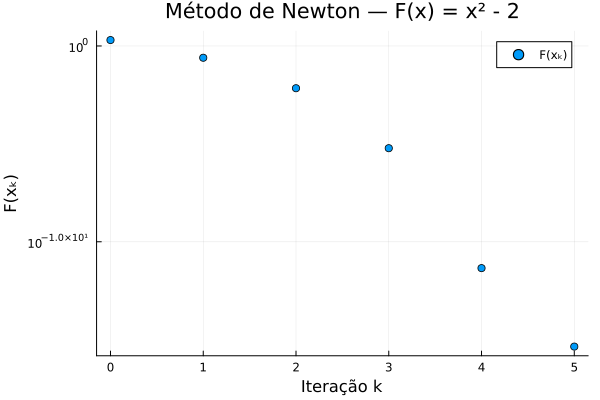

In [93]:

# Algoritmo 7.2 - Método de Newton (uma variável)
# F(x) = x² - 2 = 0, x₀ = 2, ε = 1e-15

using Printf
using Plots

# Definição das funções
F(x)  = x^2 - 2.0
dF(x) = 2.0 * x

# Parâmetros
x = 2.0
ε = 1e-15
k = 0

# Cabeçalho da tabela
println("k \t xk \t\t\t F(xk) \t\t\t F'(xk)")

# Armazenar iterações para o gráfico
ks = Int[]
Fxs = Float64[]

# Guardar primeiro ponto
push!(ks, k)
push!(Fxs, F(x))
@printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x, F(x), dF(x))

# Loop principal
while abs(F(x)) >= ε
    x = x - F(x) / dF(x)
    k += 1
    push!(ks, k)
    push!(Fxs, F(x))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x, F(x), dF(x))
end

println("\nx* = ", x)

# Gráfico: iterações × F(xk)
plot(ks, Fxs,
    seriestype = :scatter,
    xlabel = "Iteração k",
    ylabel = "F(xₖ)",
    title = "Método de Newton — F(x) = x² - 2",
    label = "F(xₖ)",
    marker = :circle,
    yscale = :log10,
    yformatter = :scientific,
    legend = :topright
)

Another example: $F(x)=x-\sin(x)$. Run the example with $x_0=1$ and $\varepsilon=10^{-15}$.

k 	 xk 			 F(xk) 			 F'(xk)
0 	 +1.00000000E+00 	 +1.58529015E-01 	 +4.59697694E-01
1 	 +6.55145072E-01 	 +4.58707860E-02 	 +2.07040452E-01
2 	 +4.33590368E-01 	 +1.34587380E-02 	 +9.25368255E-02
3 	 +2.88148401E-01 	 +3.97094846E-03 	 +4.12282985E-02
4 	 +1.91832312E-01 	 +1.17439692E-03 	 +1.83434616E-02
5 	 +1.27809668E-01 	 +3.47684349E-04 	 +8.15654318E-03
6 	 +8.51832336E-02 	 +1.02980157E-04 	 +3.62589833E-03
7 	 +5.67819528E-02 	 +3.05077170E-05 	 +1.61166199E-03
8 	 +3.78526008E-02 	 +9.03867580E-06 	 +7.16324157E-04
9 	 +2.52344645E-02 	 +2.67804088E-06 	 +3.18372205E-04
10 	 +1.68227978E-02 	 +7.93482367E-07 	 +1.41499926E-04
11 	 +1.12151456E-02 	 +2.35104408E-07 	 +6.28890867E-05
12 	 +7.47674809E-03 	 +6.96603706E-08 	 +2.79507508E-05
13 	 +4.98449408E-03 	 +2.06400842E-08 	 +1.24225649E-05
14 	 +3.32299468E-03 	 +6.11557712E-09 	 +5.52114173E-06
15 	 +2.21532938E-03 	 +1.81202240E-09 	 +2.45384112E-06
16 	 +1.47688613E-03 	 +5.36895469E-10 	 +1.09059612E-06
17 	 +9.84590

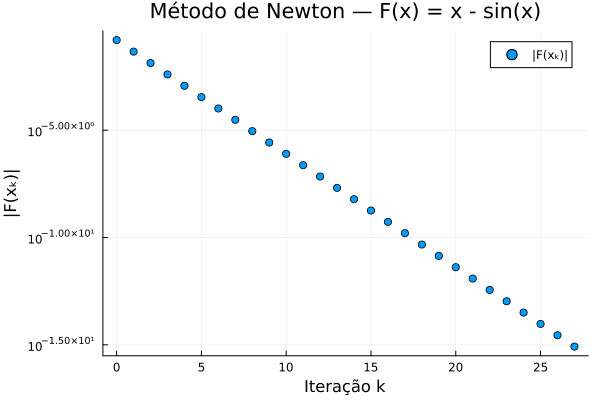

In [94]:
# Algoritmo 7.2 - Método de Newton (uma variável)
# F(x) = x - sin(x) = 0, x₀ = 1, ε = 1e-15

using Printf
using Plots

# Definição das funções
F(x)  = x - sin(x)
dF(x) = 1.0 - cos(x)

# Parâmetros
x = 1.0
ε = 1e-15
k = 0

# Armazenar iterações para o gráfico
ks = Int[]
Fxs = Float64[]

# Cabeçalho da tabela
println("k \t xk \t\t\t F(xk) \t\t\t F'(xk)")

# Guardar primeiro ponto
push!(ks, k)
push!(Fxs, abs(F(x)))
@printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x, F(x), dF(x))

# Loop principal
while abs(F(x)) >= ε
    x = x - F(x) / dF(x)
    k += 1
    push!(ks, k)
    push!(Fxs, abs(F(x)))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x, F(x), dF(x))
end

println("\nx* = ", x)

# Gráfico: iterações × |F(xk)|
plot(ks, Fxs,
    seriestype = :scatter,
    xlabel = "Iteração k",
    ylabel = "|F(xₖ)|",
    title = "Método de Newton — F(x) = x - sin(x)",
    label = "|F(xₖ)|",
    marker = :circle,
    yscale = :log10,
    yformatter = :scientific,
    legend = :topright
)

Another example: $F(x)=\arctan(x)$. Run the example with $x_0=1.5$ and $\varepsilon=10^{-15}$. We set `maxiter` to 10, as the algorithm is not converging.

k 	 xk 			 F(xk) 			 F'(xk)
0 	 +1.50000000E+00 	 +9.82793723E-01 	 +3.07692308E-01
1 	 -1.69407960E+00 	 -1.03754636E+00 	 +2.58404230E-01
2 	 +2.32112696E+00 	 +1.16400204E+00 	 +1.56552578E-01
3 	 -5.11408784E+00 	 -1.37769453E+00 	 +3.68271300E-02
4 	 +3.22956839E+01 	 +1.53984233E+00 	 +9.57844131E-04
5 	 -1.57531695E+03 	 -1.57016153E+00 	 +4.02961851E-07
6 	 +3.89497601E+06 	 +1.57079607E+00 	 +6.59159364E-14
7 	 -2.38302890E+13 	 -1.57079633E+00 	 +1.76092712E-27
8 	 +8.92028016E+26 	 +1.57079633E+00 	 +1.25673298E-54
9 	 -1.24990460E+54 	 -1.57079633E+00 	 +6.40097701E-109
10 	 +2.45399464E+108 	 +1.57079633E+00 	 +1.66055315E-217

⚠️  Número máximo de iterações atingido (maxiter = 10). Não convergiu.


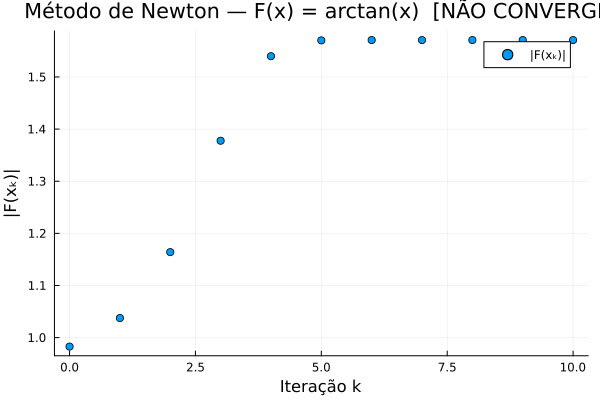

In [95]:
# Algoritmo 7.2 - Método de Newton (uma variável)
# F(x) = arctan(x) = 0, x₀ = 1.5, ε = 1e-15, maxiter = 10

using Printf
using Plots

# Definição das funções
F(x)  = atan(x)
dF(x) = 1.0 / (1.0 + x^2)

# Parâmetros
x = 1.5
ε = 1e-15
k = 0
maxiter = 10

# Armazenar iterações para o gráfico
ks = Int[]
Fxs = Float64[]

# Cabeçalho da tabela
println("k \t xk \t\t\t F(xk) \t\t\t F'(xk)")

# Guardar primeiro ponto
push!(ks, k)
push!(Fxs, abs(F(x)))
@printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x, F(x), dF(x))

# Loop principal
while abs(F(x)) >= ε && k < maxiter
    x = x - F(x) / dF(x)
    k += 1
    push!(ks, k)
    push!(Fxs, abs(F(x)))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x, F(x), dF(x))
end

if k == maxiter
    println("\n⚠️  Número máximo de iterações atingido (maxiter = $maxiter). Não convergiu.")
else
    println("\nx* = ", x)
end

# Gráfico: iterações × |F(xk)|
plot(ks, Fxs,
    seriestype = :scatter,
    xlabel = "Iteração k",
    ylabel = "|F(xₖ)|",
    title = "Método de Newton — F(x) = arctan(x)  [NÃO CONVERGE]",
    label = "|F(xₖ)|",
    marker = :circle,
    legend = :topright
)

### Algorithm 7.3: Newton's method: $n$ variables

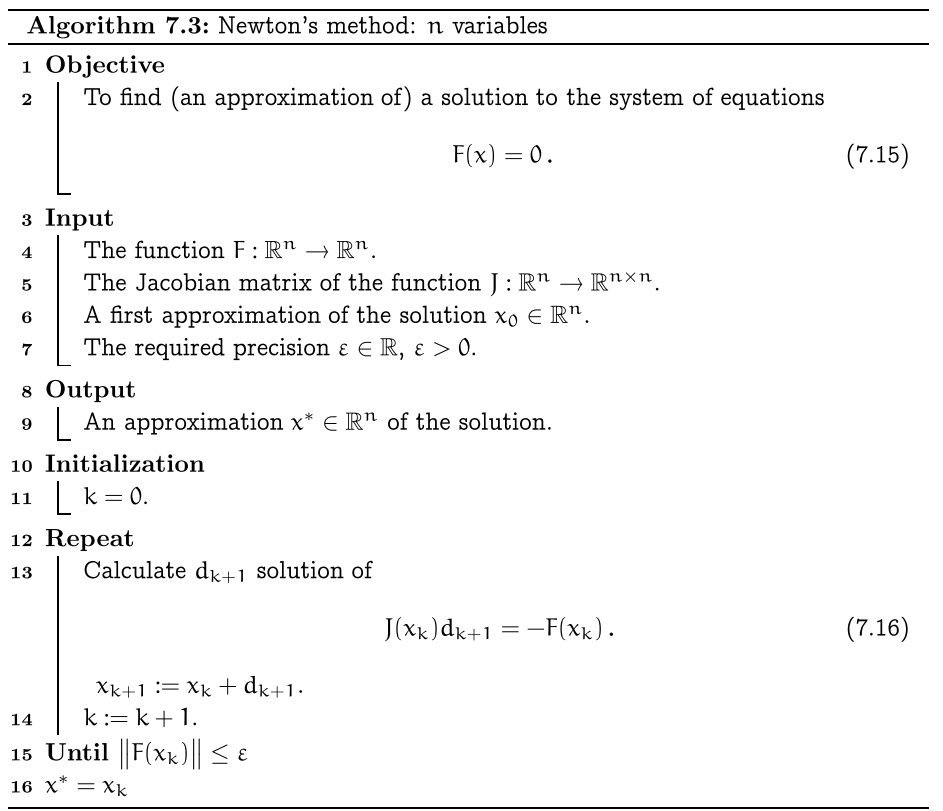

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

k 	 x1 			 x2 			 ||F(xk)||
0 	 +1.00000000E+00 	 +1.00000000E+00 	 +3.45723769E+00
1 	 +1.52359214E-01 	 +1.19528157E+00 	 +1.15470871E+00
2 	 -1.08376809E-02 	 +1.03611117E+00 	 +1.14042558E-01
3 	 -8.89664601E-04 	 +1.00153532E+00 	 +3.94232976E-03
4 	 -1.37008875E-06 	 +1.00000294E+00 	 +8.07998556E-06
5 	 -5.53845220E-12 	 +1.00000000E+00 	 +2.88311226E-11
6 	 -1.04637936E-16 	 +1.00000000E+00 	 +4.44089210E-16

x* = [-1.0463793574265223e-16, 1.0000000000000002]


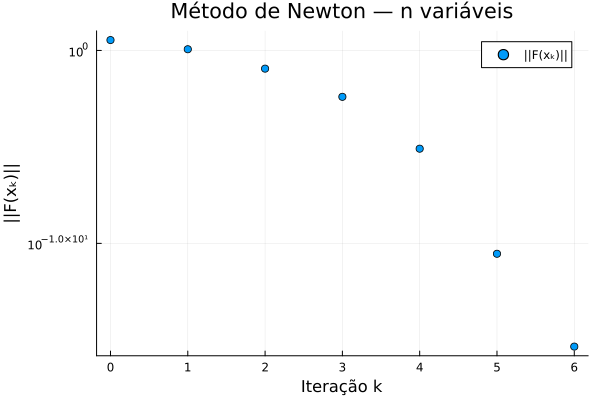

In [96]:
# Algoritmo 7.3 - Método de Newton (n variáveis)
# F(x) = [(x1+1)² + x2² - 2 ; exp(x1) + x2³ - 2]
# x₀ = [1, 1], ε = 1e-15

using Printf
using LinearAlgebra
using Plots

# Definição de F(x) e J(x)
function F(x)
    return [
        (x[1] + 1)^2 + x[2]^2 - 2.0,
        exp(x[1]) + x[2]^3 - 2.0
    ]
end

function J(x)
    return [
        2*(x[1]+1)   2*x[2];
        exp(x[1])    3*x[2]^2
    ]
end

# Parâmetros
x = [1.0, 1.0]
ε = 1e-15
k = 0

# Armazenar iterações para o gráfico
ks = Int[]
norms = Float64[]

# Cabeçalho
println("k \t x1 \t\t\t x2 \t\t\t ||F(xk)||")

push!(ks, k)
push!(norms, norm(F(x)))
@printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))

# Loop principal
while norm(F(x)) >= ε
    d = J(x) \ (-F(x))   # Resolve J(xk) * d = -F(xk)
    x = x + d
    k += 1
    push!(ks, k)
    push!(norms, norm(F(x)))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))
end

println("\nx* = [", x[1], ", ", x[2], "]")

# Gráfico: iterações × ||F(xk)||
plot(ks, norms,
    seriestype = :scatter,
    xlabel = "Iteração k",
    ylabel = "||F(xₖ)||",
    title = "Método de Newton — n variáveis",
    label = "||F(xₖ)||",
    marker = :circle,
    yscale = :log10,
    yformatter = :scientific,
    legend = :topright
)

Example: $F(x)=\left(\begin{array}{c}x_1^3 - 3 x_1 x_2^2 -1 \\ x_2^3 - 3x_1^2 x_2\end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

k 	 x1 			 x2 			 ||F(xk)||
0 	 +1.00000000E+00 	 +1.00000000E+00 	 +3.60555128E+00
1 	 +6.66666667E-01 	 +5.00000000E-01 	 +1.31996416E+00
2 	 +5.78844444E-01 	 -1.27466667E-01 	 +8.43736321E-01
3 	 +1.24696398E+00 	 +3.13578425E-01 	 +1.54161108E+00
4 	 +1.00894820E+00 	 +1.13677965E-01 	 +3.45904691E-01
5 	 +9.87868046E-01 	 +3.83684364E-03 	 +3.77115051E-02
6 	 +1.00013414E+00 	 -9.53221851E-05 	 +4.93755294E-04
7 	 +1.00000001E+00 	 -2.55681329E-08 	 +8.12284357E-08
8 	 +1.00000000E+00 	 -4.55624452E-16 	 +2.15445629E-15
9 	 +1.00000000E+00 	 +4.93038066E-31 	 +1.47911420E-30


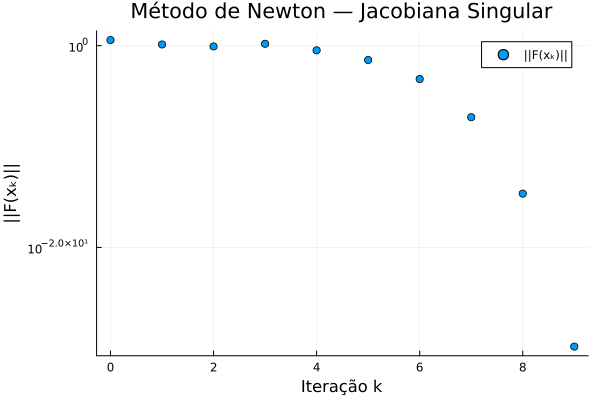

In [97]:
# Algoritmo 7.3 - Método de Newton (n variáveis)
# F(x) = [x1³ - 3x1x2² - 1 ; x2³ - 3x1²x2]
# x₀ = [1, 1], ε = 1e-15

using Printf
using LinearAlgebra
using Plots

# Definição de F(x) e J(x)
function F(x)
    return [
        x[1]^3 - 3*x[1]*x[2]^2 - 1.0,
        x[2]^3 - 3*x[1]^2*x[2]
    ]
end

function J(x)
    return [
        3*x[1]^2 - 3*x[2]^2    -6*x[1]*x[2];
       -6*x[1]*x[2]              3*x[2]^2 - 3*x[1]^2
    ]
end

# Parâmetros
x = [1.0, 1.0]
ε = 1e-15
k = 0
maxiter = 50  # segurança, pois J é singular

# Armazenar iterações para o gráfico
ks = Int[]
norms = Float64[]

# Cabeçalho
println("k \t x1 \t\t\t x2 \t\t\t ||F(xk)||")

push!(ks, k)
push!(norms, norm(F(x)))
@printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))

# Loop principal
while norm(F(x)) >= ε && k < maxiter
    Jk = J(x)
    if abs(det(Jk)) < 1e-14
        println("\n⚠️  Jacobiana singular ou quase-singular na iteração k=$k. det(J) = $(det(Jk))")
        break
    end
    d = Jk \ (-F(x))
    x = x + d
    k += 1
    push!(ks, k)
    push!(norms, norm(F(x)))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))
end

if k == maxiter
    println("\n⚠️  Máximo de iterações atingido sem convergência.")
end

# Gráfico: iterações × ||F(xk)||
plot(ks, norms,
    seriestype = :scatter,
    xlabel = "Iteração k",
    ylabel = "||F(xₖ)||",
    title = "Método de Newton — Jacobiana Singular",
    label = "||F(xₖ)||",
    marker = :circle,
    yscale = :log10,
    yformatter = :scientific,
    legend = :topright
)

Run the example with $x_0= \left(\begin{array}{c} -1 \\ -1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

k 	 x1 			 x2 			 ||F(xk)||
0 	 -1.00000000E+00 	 -1.00000000E+00 	 +2.23606798E+00
1 	 -6.66666667E-01 	 -8.33333333E-01 	 +5.40398960E-01
2 	 -5.08691916E-01 	 -8.41099874E-01 	 +7.78404264E-02
3 	 -4.99329996E-01 	 -8.66269172E-01 	 +2.13865036E-03
4 	 -4.99999911E-01 	 -8.66024903E-01 	 +1.52523667E-06
5 	 -5.00000000E-01 	 -8.66025404E-01 	 +7.75299009E-13
6 	 -5.00000000E-01 	 -8.66025404E-01 	 +2.48253415E-16

x* = [-0.49999999999999994, -0.8660254037844386]


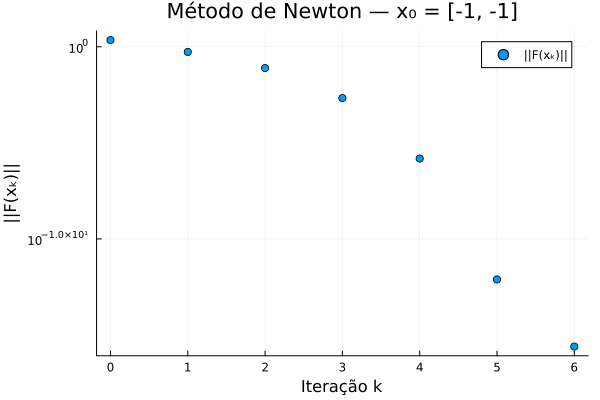

In [98]:
# Algoritmo 7.3 - Método de Newton (n variáveis)
# F(x) = [x1³ - 3x1x2² - 1 ; x2³ - 3x1²x2]
# x₀ = [-1, -1], ε = 1e-15

using Printf
using LinearAlgebra
using Plots

function F(x)
    return [
        x[1]^3 - 3*x[1]*x[2]^2 - 1.0,
        x[2]^3 - 3*x[1]^2*x[2]
    ]
end

function J(x)
    return [
        3*x[1]^2 - 3*x[2]^2    -6*x[1]*x[2];
       -6*x[1]*x[2]              3*x[2]^2 - 3*x[1]^2
    ]
end

# Parâmetros
x = [-1.0, -1.0]   # <-- único ponto alterado
ε = 1e-15
k = 0
maxiter = 50

ks = Int[]
norms = Float64[]

println("k \t x1 \t\t\t x2 \t\t\t ||F(xk)||")

push!(ks, k)
push!(norms, norm(F(x)))
@printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))

while norm(F(x)) >= ε && k < maxiter
    Jk = J(x)
    if abs(det(Jk)) < 1e-14
        println("\n⚠️  Jacobiana singular na iteração k=$k. det(J) = $(det(Jk))")
        break
    end
    d = Jk \ (-F(x))
    x = x + d
    k += 1
    push!(ks, k)
    push!(norms, norm(F(x)))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))
end

if k == maxiter
    println("\n⚠️  Máximo de iterações atingido sem convergência.")
else
    println("\nx* = [", x[1], ", ", x[2], "]")
end

plot(ks, norms,
    seriestype = :scatter,
    xlabel = "Iteração k",
    ylabel = "||F(xₖ)||",
    title = "Método de Newton — x₀ = [-1, -1]",
    label = "||F(xₖ)||",
    marker = :circle,
    yscale = :log10,
    yformatter = :scientific,
    legend = :topright
)

Run the example with $x_0= \left(\begin{array}{c} 0 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

k 	 x1 			 x2 			 ||F(xk)||
0 	 +0.00000000E+00 	 +1.00000000E+00 	 +1.41421356E+00
1 	 -3.33333333E-01 	 +6.66666667E-01 	 +5.97204278E-01
2 	 -5.82222222E-01 	 +9.24444444E-01 	 +3.31281254E-01
3 	 -5.08790803E-01 	 +8.68165512E-01 	 +2.73128276E-02
4 	 -5.00068739E-01 	 +8.65982219E-01 	 +2.43535921E-04
5 	 -4.99999996E-01 	 +8.66025398E-01 	 +1.97701144E-08
6 	 -5.00000000E-01 	 +8.66025404E-01 	 +4.96506831E-16

x* = [-0.5000000000000001, 0.8660254037844387]


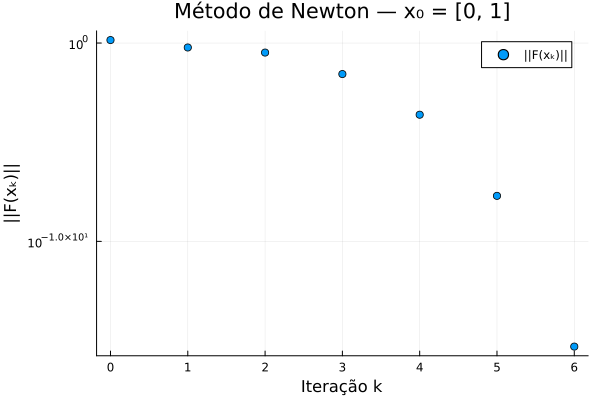

In [99]:
# Algoritmo 7.3 - Método de Newton (n variáveis)
# F(x) = [x1³ - 3x1x2² - 1 ; x2³ - 3x1²x2]
# x₀ = [0, 1], ε = 1e-15

using Printf
using LinearAlgebra
using Plots

function F(x)
    return [
        x[1]^3 - 3*x[1]*x[2]^2 - 1.0,
        x[2]^3 - 3*x[1]^2*x[2]
    ]
end

function J(x)
    return [
        3*x[1]^2 - 3*x[2]^2    -6*x[1]*x[2];
       -6*x[1]*x[2]              3*x[2]^2 - 3*x[1]^2
    ]
end

# Parâmetros
x = [0.0, 1.0]   # <-- ponto inicial alterado
ε = 1e-15
k = 0
maxiter = 50

ks = Int[]
norms = Float64[]

println("k \t x1 \t\t\t x2 \t\t\t ||F(xk)||")

push!(ks, k)
push!(norms, norm(F(x)))
@printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))

while norm(F(x)) >= ε && k < maxiter
    Jk = J(x)
    if abs(det(Jk)) < 1e-14
        println("\n⚠️  Jacobiana singular na iteração k=$k. det(J) = $(det(Jk))")
        break
    end
    d = Jk \ (-F(x))
    x = x + d
    k += 1
    push!(ks, k)
    push!(norms, norm(F(x)))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))
end

if k == maxiter
    println("\n⚠️  Máximo de iterações atingido sem convergência.")
else
    println("\nx* = [", x[1], ", ", x[2], "]")
end

plot(ks, norms,
    seriestype = :scatter,
    xlabel = "Iteração k",
    ylabel = "||F(xₖ)||",
    title = "Método de Newton — x₀ = [0, 1]",
    label = "||F(xₖ)||",
    marker = :circle,
    yscale = :log10,
    yformatter = :scientific,
    legend = :topright
)